In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb

# Load the same ML-ready data
ml_df = pd.read_csv('../data/processed/trip_level_ml_ready.csv')

# This time our target is delay_flag (0 = On Time, 1 = Delayed) - a classification problem
# Check class balance first - this matters a lot for classification
print(ml_df['delay_flag'].value_counts())
print(ml_df['delay_flag'].value_counts(normalize=True) * 100)

delay_flag
1    14229
0      558
Name: count, dtype: int64
delay_flag
1    96.226415
0     3.773585
Name: proportion, dtype: float64


In [2]:
# Same leakage columns as before - actual_time itself must also be dropped now,
# since actual_time is literally used to calculate delay_flag (delay_flag comes from it)
leakage_cols = ['actual_time', 'osrm_error', 'delay_percentage', 'time_efficiency', 
                 'trip_duration_minutes', 'trip_duration_hours', 'start_scan_to_end_scan',
                 'segment_actual_time', 'actual_distance_to_destination', 'route_efficiency']

ml_df_clf = ml_df.drop(columns=leakage_cols, errors='ignore')

# Separate features and target
X_clf = ml_df_clf.drop(columns=['delay_flag'])
y_clf = ml_df_clf['delay_flag']

# Convert boolean columns to 0/1
X_clf['is_interstate'] = X_clf['is_interstate'].astype(int)
X_clf['is_weekend'] = X_clf['is_weekend'].astype(int)

# Same encoding strategy as Model 1
low_card_cols = ['route_type', 'distance_category', 'creation_day_name']
X_clf_encoded = pd.get_dummies(X_clf, columns=low_card_cols, drop_first=True)

from sklearn.preprocessing import LabelEncoder
high_card_cols = ['source_state', 'destination_state', 'source_city_code', 
                   'destination_city_code', 'corridor_id']

for col in high_card_cols:
    le = LabelEncoder()
    X_clf_encoded[col] = le.fit_transform(X_clf_encoded[col].astype(str))

print("Final feature shape:", X_clf_encoded.shape)

Final feature shape: (14787, 26)


In [3]:
# stratify=y_clf ensures both train and test sets keep the same 96/4 class ratio
# Without this, a random split could accidentally put very few "On Time" examples in the test set
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf_encoded, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train class balance:\n", y_train_c.value_counts(normalize=True))
print("\nTest class balance:\n", y_test_c.value_counts(normalize=True))

Train class balance:
 delay_flag
1    0.962296
0    0.037704
Name: proportion, dtype: float64

Test class balance:
 delay_flag
1    0.962137
0    0.037863
Name: proportion, dtype: float64


In [4]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

clf_results = []

# Model 1: Logistic Regression with class_weight='balanced'
# class_weight='balanced' tells the model to penalize mistakes on the minority class (On Time) 
# more heavily, so it doesn't just ignore that class to chase accuracy
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_c, y_train_c)
log_pred = log_reg.predict(X_test_c)
log_proba = log_reg.predict_proba(X_test_c)[:, 1]

clf_results.append({
    'Model': 'Logistic Regression',
    'F1 (On-Time class)': f1_score(y_test_c, log_pred, pos_label=0),
    'F1 (Delayed class)': f1_score(y_test_c, log_pred, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test_c, log_proba)
})

# Model 2: Random Forest with class_weight='balanced'
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', 
                                  random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
rf_pred = rf_clf.predict(X_test_c)
rf_proba = rf_clf.predict_proba(X_test_c)[:, 1]

clf_results.append({
    'Model': 'Random Forest',
    'F1 (On-Time class)': f1_score(y_test_c, rf_pred, pos_label=0),
    'F1 (Delayed class)': f1_score(y_test_c, rf_pred, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test_c, rf_proba)
})

# Model 3: XGBoost - scale_pos_weight handles imbalance for XGBoost specifically
# (ratio of majority to minority class, tells XGBoost to focus more on minority class)
scale_pos_weight = (y_train_c == 1).sum() / (y_train_c == 0).sum()
xgb_clf = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                              scale_pos_weight=1/scale_pos_weight, random_state=42)
xgb_clf.fit(X_train_c, y_train_c)
xgb_pred = xgb_clf.predict(X_test_c)
xgb_proba = xgb_clf.predict_proba(X_test_c)[:, 1]

clf_results.append({
    'Model': 'XGBoost',
    'F1 (On-Time class)': f1_score(y_test_c, xgb_pred, pos_label=0),
    'F1 (Delayed class)': f1_score(y_test_c, xgb_pred, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test_c, xgb_proba)
})

clf_results_df = pd.DataFrame(clf_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
clf_results_df

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,F1 (On-Time class),F1 (Delayed class),ROC-AUC
0,XGBoost,0.400000,0.952381,0.941271
1,Random Forest,0.511848,0.981946,0.933337
2,Logistic Regression,0.172676,0.820650,0.820349


In [5]:
from sklearn.preprocessing import StandardScaler

# Logistic Regression is sensitive to feature scale - standardize features 
# so they're all on a comparable range (mean=0, std=1). Tree-based models (RF, XGBoost) don't need this.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_c)
log_pred = log_reg.predict(X_test_scaled)
log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Update the first row in clf_results_df with corrected values
clf_results_df.loc[clf_results_df['Model'] == 'Logistic Regression', 'F1 (On-Time class)'] = f1_score(y_test_c, log_pred, pos_label=0)
clf_results_df.loc[clf_results_df['Model'] == 'Logistic Regression', 'F1 (Delayed class)'] = f1_score(y_test_c, log_pred, pos_label=1)
clf_results_df.loc[clf_results_df['Model'] == 'Logistic Regression', 'ROC-AUC'] = roc_auc_score(y_test_c, log_proba)

clf_results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

,Model,F1 (On-Time class),F1 (Delayed class),ROC-AUC
0,XGBoost,0.400000,0.952381,0.941271
1,Random Forest,0.511848,0.981946,0.933337
2,Logistic Regression,0.153713,0.794031,0.807587


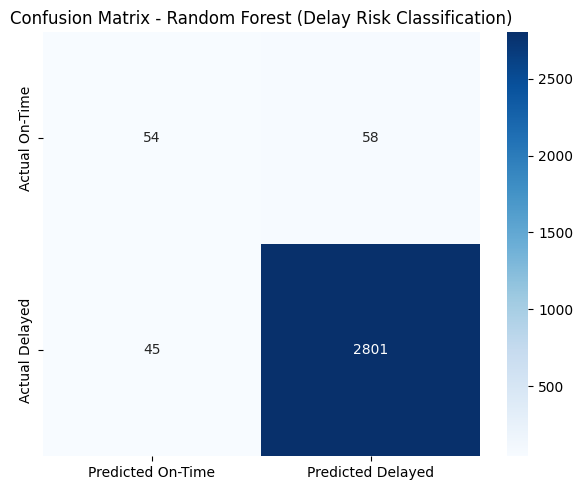

              precision    recall  f1-score   support

     On-Time       0.55      0.48      0.51       112
     Delayed       0.98      0.98      0.98      2846

    accuracy                           0.97      2958
   macro avg       0.76      0.73      0.75      2958
weighted avg       0.96      0.97      0.96      2958



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_c, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted On-Time', 'Predicted Delayed'],
            yticklabels=['Actual On-Time', 'Actual Delayed'])
plt.title('Confusion Matrix - Random Forest (Delay Risk Classification)')
plt.tight_layout()
plt.show()

print(classification_report(y_test_c, rf_pred, target_names=['On-Time', 'Delayed']))

In [8]:
import joblib
import os
joblib.dump(rf_clf, '../models/delay_risk_model.pkl')
joblib.dump(scaler, '../models/scaler_delay_risk.pkl')
print("Delay risk model saved!")

Delay risk model saved!
